# Régression linéaire sur l'indice de performance

Objectif : explorer un modèle simple pour estimer le temps qu'un coureur aurait pu réaliser sur une course qu'il a effectivement couru (sert de validation au modele et aussi pour voir si le coureur sur ou sous-performe) ou sur une course qu'il n'a pas couru (sorte de point de repère si la meme course se présente dans le futur).

L'idée est de prédire d'abord le z-score de performance (`target_z`). Ce z-score est ensuite transformé en vitesse puis en temps grâce aux caractéristiques de la course.

Le notebook charge les données depuis PostgreSQL, car c'est la source structurée du projet après le chargement et le feature engineering.


In [32]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.loading.db_config import engine


## Chargement depuis la base

La table `fact_runner_race_analysis` est une table de faits analytique au même grain qu'un résultat : un coureur sur une course. Elle partage les dimensions `dim_runner` et `dim_race` avec `fact_results`, mais elle ne crée pas de relation fact-to-fact. La colonne `source_result_id` sert seulement à retrouver la ligne d'origine si nécessaire.


In [33]:
query = """
SELECT
    a.analysis_id,
    a.source_result_id,
    a.runner_id,
    r.name_clean AS runner_name,
    a.race_id,
    a.actual_time_sec AS target_time_sec,
    ra.name AS race_name,
    ra.distance,
    ra.date,
    ra.year,
    EXTRACT(MONTH FROM ra.date)::int AS race_month,
    EXTRACT(DOY FROM ra.date)::int AS race_dayofyear,
    a.race_mean_speed,
    a.race_std_speed,
    a.prior_race_count,
    a.prior_avg_speed,
    a.prior_std_speed,
    a.prior_best_speed,
    a.prior_avg_z,
    a.prior_std_z,
    a.prior_best_z,
    a.recent_speed_roll3,
    a.recent_z_roll3,
    a.days_since_last_race,
    a.runner_history_years,
    a.target_z
FROM fact_runner_race_analysis a
JOIN dim_race ra ON a.race_id = ra.race_id
JOIN dim_runner r ON a.runner_id = r.runner_id
"""

df = pd.read_sql(query, engine)
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()


(80216, 26)


,analysis_id,source_result_id,runner_id,runner_name,race_id,target_time_sec,race_name,distance,date,year,...,prior_std_speed,prior_best_speed,prior_avg_z,prior_std_z,prior_best_z,recent_speed_roll3,recent_z_roll3,days_since_last_race,runner_history_years,target_z
0,69,72263,1,SIMONET YVES,363,2548.0,La Condrusienne - Solieres,11.50,2017-06-09,2017,...,1.696764,18.225291,2.369320,0.851372,3.331678,15.700033,2.598334,21.0,10.672142,2.869818
1,70,112597,1,SIMONET YVES,557,2513.0,Le Jogging De La Piscine - Ocquier,11.20,2017-06-23,2017,...,1.684995,18.225291,2.376369,0.847354,3.331678,15.833888,2.661978,14.0,10.710472,2.812570
2,71,102514,1,SIMONET YVES,507,3391.0,Les Foulees De Tihange,13.00,2018-03-25,2018,...,1.673128,18.225291,2.382428,0.842934,3.331678,15.670505,2.607318,275.0,11.463381,1.509340
3,72,21033,1,SIMONET YVES,101,2608.0,Le Jogging De Terwagne,12.00,2018-04-13,2018,...,1.680332,18.225291,2.370468,0.843274,3.331678,15.364615,2.397243,19.0,11.515400,2.441215
4,73,12858,1,SIMONET YVES,63,2329.0,Le Jogging De Pailhe,10.31,2018-04-20,2018,...,1.670479,18.225291,2.371424,0.837519,3.331678,15.470075,2.254375,7.0,11.534565,2.591029


## Sélection des variables

On garde volontairement un nombre limité de variables. La distance est conservée telle quelle via `distance`. On ne crée pas de segmentation courte/moyenne/longue, afin de garder suffisamment d'observations pour chaque coureur.


In [34]:
FEATURE_COLUMNS = [
    "distance",
    "race_month",
    "race_dayofyear",
    "prior_race_count",
    "prior_avg_speed",
    "prior_std_speed",
    "prior_best_speed",
    "prior_avg_z",
    "prior_std_z",
    "prior_best_z",
    "recent_speed_roll3",
    "recent_z_roll3",
    "days_since_last_race",
    "runner_history_years",
]

TARGET = "target_z"

data = df.replace([np.inf, -np.inf], np.nan).copy()
data = data.dropna(subset=[TARGET, "target_time_sec", "race_mean_speed", "race_std_speed"])

print("Nombre de lignes utilisables:", len(data))
data[FEATURE_COLUMNS + [TARGET, "target_time_sec"]].head()


Nombre de lignes utilisables: 80216


,distance,race_month,race_dayofyear,prior_race_count,prior_avg_speed,prior_std_speed,prior_best_speed,prior_avg_z,prior_std_z,prior_best_z,recent_speed_roll3,recent_z_roll3,days_since_last_race,runner_history_years,target_z,target_time_sec
0,11.50,6,160,70,15.940684,1.696764,18.225291,2.369320,0.851372,3.331678,15.700033,2.598334,21.0,10.672142,2.869818,2548.0
1,11.20,6,174,71,15.945013,1.684995,18.225291,2.376369,0.847354,3.331678,15.833888,2.661978,14.0,10.710472,2.812570,2513.0
2,13.00,3,84,72,15.946396,1.673128,18.225291,2.382428,0.842934,3.331678,15.670505,2.607318,275.0,11.463381,1.509340,3391.0
3,12.00,4,103,73,15.917010,1.680332,18.225291,2.370468,0.843274,3.331678,15.364615,2.397243,19.0,11.515400,2.441215,2608.0
4,10.31,4,110,74,15.925759,1.670479,18.225291,2.371424,0.837519,3.331678,15.470075,2.254375,7.0,11.534565,2.591029,2329.0


## Split temporel

On entraîne sur les années passées et on teste sur l'année la plus récente disponible.

In [43]:
years = sorted(data["year"].dropna().unique())
test_year = years[-1]

train_df = data[data["year"] < test_year].copy()
test_df = data[data["year"] == test_year].copy()

print("Année de test:", test_year)
print("Train:", train_df.shape)
print("Test :", test_df.shape)


Année de test: 2025
Train: (74589, 26)
Test : (5627, 26)


## Modèle de régression linéaire

Remplacement des valeurs manquantes par la médiane, standardisation des variables, puis régression linéaire.


In [36]:
model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

model.fit(train_df[FEATURE_COLUMNS], train_df[TARGET])


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## Conversion du z-score en temps

Le modèle prédit un z-score. Pour obtenir un temps, on reconstruit une vitesse estimée à partir de la moyenne et de l'écart-type de la course.


In [37]:
def predict_with_time(input_df, split_name):
    pred = input_df[[
        "analysis_id",
        "source_result_id",
        "runner_id",
        "runner_name",
        "race_id",
        "race_name",
        "distance",
        "target_z",
        "target_time_sec",
        "race_mean_speed",
        "race_std_speed",
    ]].copy()

    pred["split"] = split_name
    pred["predicted_z"] = model.predict(input_df[FEATURE_COLUMNS])
    pred["predicted_performance_index"] = 100 + 10 * pred["predicted_z"]
    pred["predicted_speed_kmh"] = (
        pred["race_mean_speed"] + pred["predicted_z"] * pred["race_std_speed"]
    ).clip(lower=1)
    pred["predicted_time_sec"] = pred["distance"] / pred["predicted_speed_kmh"] * 3600
    pred["abs_error_time_sec"] = (
        pred["target_time_sec"] - pred["predicted_time_sec"]
    ).abs()
    return pred

train_pred = predict_with_time(train_df, "train")
test_pred = predict_with_time(test_df, "test")


## Qualité du modèle

On compare les métriques sur train et test pour vérifier si le modèle généralise. Un gros écart en faveur du train indiquerait du surapprentissage.


In [38]:
def compute_metrics(pred):
    return {
        "n": len(pred),
        "mae_z": mean_absolute_error(pred["target_z"], pred["predicted_z"]),
        "rmse_z": mean_squared_error(pred["target_z"], pred["predicted_z"]) ** 0.5,
        "r2_z": r2_score(pred["target_z"], pred["predicted_z"]),
        "mae_time_sec": pred["abs_error_time_sec"].mean(),
        "rmse_time_sec": mean_squared_error(
            pred["target_time_sec"],
            pred["predicted_time_sec"],
        ) ** 0.5,
    }

metrics = pd.DataFrame([
    {"jeu": "train", **compute_metrics(train_pred)},
    {"jeu": "test", **compute_metrics(test_pred)},
])
metrics.round(3)


,jeu,n,mae_z,rmse_z,r2_z,mae_time_sec,rmse_time_sec
0,train,74589,0.331,0.481,0.771,216.571,474.279
1,test,5627,0.335,0.473,0.778,200.406,313.850


In [39]:
overfitting = pd.DataFrame({
    "mesure": ["R2 z", "MAE temps (secondes)"],
    "train": [metrics.loc[0, "r2_z"], metrics.loc[0, "mae_time_sec"]],
    "test": [metrics.loc[1, "r2_z"], metrics.loc[1, "mae_time_sec"]],
})
overfitting["ecart_test_moins_train"] = overfitting["test"] - overfitting["train"]
overfitting.round(3)


,mesure,train,test,ecart_test_moins_train
0,R2 z,0.771,0.778,0.007
1,MAE temps (secondes),216.571,200.406,-16.165


## Variables les plus influentes


In [40]:
coefficients = pd.DataFrame({
    "variable": FEATURE_COLUMNS,
    "coefficient": model.named_steps["model"].coef_,
})
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients.sort_values("abs_coefficient", ascending=False).head(15).round(4)


,variable,coefficient,abs_coefficient
11,recent_z_roll3,0.5118,0.5118
4,prior_avg_speed,0.2894,0.2894
0,distance,-0.1387,0.1387
7,prior_avg_z,0.1055,0.1055
1,race_month,-0.0549,0.0549
10,recent_speed_roll3,0.0542,0.0542
8,prior_std_z,0.0410,0.0410
9,prior_best_z,-0.0381,0.0381
6,prior_best_speed,-0.0368,0.0368
2,race_dayofyear,0.0315,0.0315


## Visualisation des erreurs
Temps réels vs les temps prédits.


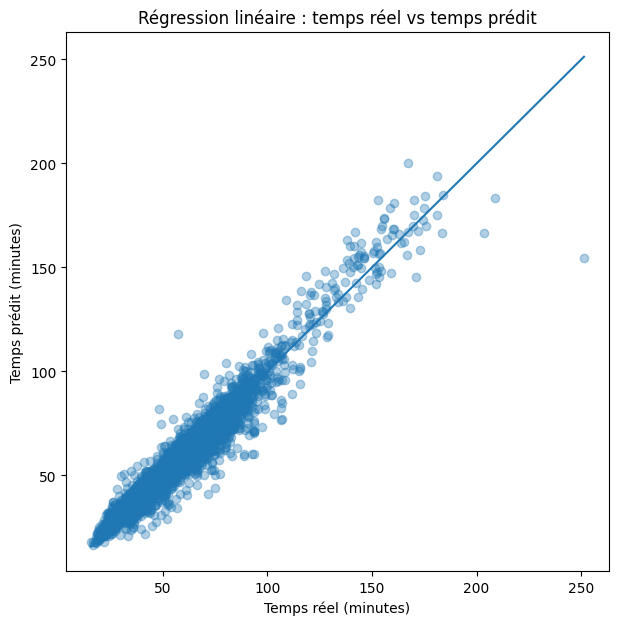

In [41]:
plt.figure(figsize=(7, 7))
plt.scatter(
    test_pred["target_time_sec"] / 60,
    test_pred["predicted_time_sec"] / 60,
    alpha=0.35,
)

min_val = min(test_pred["target_time_sec"].min(), test_pred["predicted_time_sec"].min()) / 60
max_val = max(test_pred["target_time_sec"].max(), test_pred["predicted_time_sec"].max()) / 60
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Temps réel (minutes)")
plt.ylabel("Temps prédit (minutes)")
plt.title("Régression linéaire : temps réel vs temps prédit")
plt.show()
